# Importation des packages

In [1]:
import pandas as pd
import os
import shutil
from pathlib import Path
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import timm
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
from torch.nn.functional import one_hot
from timm.data import resolve_data_config, create_transform
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from timm.data import resolve_data_config
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report  

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Chargement & Traitement des donnees 

In [5]:

# Extensions d'image à prendre en compte
extensions_valides = (".png")

# Dossier racine
dossier_source = "IDclothes_Data"

# Parcours récursif
for root, dirs, files in os.walk(dossier_source):
    nb_images = sum(1 for f in files if f.lower().endswith(extensions_valides))
    
    if nb_images > 0:
        print(f"{root} : {nb_images} image(s)")


IDclothes_Data\blousechemise : 38 image(s)
IDclothes_Data\body : 35 image(s)
IDclothes_Data\boxer_calecon : 12 image(s)
IDclothes_Data\combinaisons : 34 image(s)
IDclothes_Data\debardeur : 53 image(s)
IDclothes_Data\gilet : 16 image(s)
IDclothes_Data\jupes : 21 image(s)
IDclothes_Data\Legging-Collant : 41 image(s)
IDclothes_Data\manteau : 12 image(s)
IDclothes_Data\pantalon : 306 image(s)
IDclothes_Data\peignoir : 17 image(s)
IDclothes_Data\polos : 15 image(s)
IDclothes_Data\polos_longues_manches : 17 image(s)
IDclothes_Data\Pull-Bouton : 25 image(s)
IDclothes_Data\pulls : 177 image(s)
IDclothes_Data\Pulls-Zip : 41 image(s)
IDclothes_Data\Robes : 46 image(s)
IDclothes_Data\shorts : 42 image(s)
IDclothes_Data\soutien_gorge : 105 image(s)
IDclothes_Data\sweat : 30 image(s)
IDclothes_Data\sweat_fermeture : 34 image(s)
IDclothes_Data\teeshirt : 167 image(s)
IDclothes_Data\teeshirt_longuemanches : 195 image(s)
IDclothes_Data\veste sans manches : 6 image(s)
IDclothes_Data\vestes_col : 55 ima

In [6]:
import os
import pandas as pd

def create_image_dataframe(root_dir, extensions=[".png", ".jpg", ".jpeg"]):
    """
    Parcourt le dossier root_dir et ses sous-dossiers, et crée un DataFrame
    avec colonnes 'image_path' et 'label' (nom du sous-dossier).
    """
    data = []
    for subdir, dirs, files in os.walk(root_dir):
        label = os.path.basename(subdir)  # nom du sous-dossier = label
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                path = os.path.join(subdir, file)
                data.append({"image_path": path, "label": label})

    df = pd.DataFrame(data)
    return df

# Exemple d'utilisation
root_folder = "IDclothes_Data_process"
df_images = create_image_dataframe(root_folder)
print(df_images.head())

# Tu peux aussi sauvegarder dans un CSV si tu veux
df_images.to_csv("image_paths_labels.csv", index=False)


                                          image_path          label
0  IDclothes_Data_process\blousechemise\18_jai_st...  blousechemise
1  IDclothes_Data_process\blousechemise\19_jai_st...  blousechemise
2  IDclothes_Data_process\blousechemise\21_jai_st...  blousechemise
3  IDclothes_Data_process\blousechemise\22_jai_st...  blousechemise
4  IDclothes_Data_process\blousechemise\23_jai_st...  blousechemise


In [2]:
idclothes_df = pd.read_csv('image_paths_labels.csv')
idclothes_df.shape

(1550, 2)

In [3]:

# Dictionnaire de correspondances
label_mapping = {
    'blousechemise': 'Haut ML',
    'body': 'combinaison/body',
    'boxer_calecon': 'Bas court',
    'combinaisons': 'combinaison/body',
    'debardeur': 'Haut',
    'gilet': 'Haut ML',
    'jupes': 'Jupes',
    'Legging-Collant': 'Bas Long',
    'manteau': 'manteau',
    'pantalon': 'Bas Long',
    'peignoir': 'peignoir',
    'polos': 'Haut MC',
    'polos_longues_manches': 'Haut ML',
    'Pull-Bouton': 'Haut ML',
    'pulls': 'Haut ML',
    'Pulls-Zip': 'Haut ML',
    'Robes': 'Robes',
    'shorts': 'Bas Court',
    'soutien_gorge': 'Soutien_gorge/brassiere/Haut_maillot',
    'sweat': 'Haut ML',
    'sweat_fermeture': 'Haut ML',
    'teeshirt': 'Haut MC',
    'teeshirt_longuemanches': 'Haut ML',
    'veste_capuche': 'Haut ML',
    'vestes_col': 'Haut ML',
}

# Création de la nouvelle colonne
idclothes_df['new_label'] = idclothes_df['label'].map(label_mapping)

# Affichage du résultat
print(idclothes_df)


                                             image_path          label  \
0     IDclothes_Data_process\blousechemise\18_jai_st...  blousechemise   
1     IDclothes_Data_process\blousechemise\19_jai_st...  blousechemise   
2     IDclothes_Data_process\blousechemise\21_jai_st...  blousechemise   
3     IDclothes_Data_process\blousechemise\22_jai_st...  blousechemise   
4     IDclothes_Data_process\blousechemise\23_jai_st...  blousechemise   
...                                                 ...            ...   
1545  IDclothes_Data_process\veste_capuche\72_jai_st...  veste_capuche   
1546  IDclothes_Data_process\veste_capuche\73_jai_st...  veste_capuche   
1547  IDclothes_Data_process\veste_capuche\74_jai_st...  veste_capuche   
1548  IDclothes_Data_process\veste_capuche\75_jai_st...  veste_capuche   
1549  IDclothes_Data_process\veste_capuche\76_jai_st...  veste_capuche   

     new_label  
0      Haut ML  
1      Haut ML  
2      Haut ML  
3      Haut ML  
4      Haut ML  
...      

In [4]:
# encodage des labels
label_encoder = LabelEncoder()
idclothes_df["new_labels"] = label_encoder.fit_transform(idclothes_df["new_label"])
num_classes = len(label_encoder.classes_)

In [5]:
idclothes_df.head()

,image_path,label,new_label,new_labels
0,IDclothes_Data_process\blousechemise\18_jai_st...,blousechemise,Haut ML,5
1,IDclothes_Data_process\blousechemise\19_jai_st...,blousechemise,Haut ML,5
2,IDclothes_Data_process\blousechemise\21_jai_st...,blousechemise,Haut ML,5
3,IDclothes_Data_process\blousechemise\22_jai_st...,blousechemise,Haut ML,5
4,IDclothes_Data_process\blousechemise\23_jai_st...,blousechemise,Haut ML,5


In [6]:
# 1. Dataset personnalisé
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, resize_size=(512, 512)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.resize_size = resize_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image_path = row["image_path"]
            label = row["new_labels"]

            image = Image.open(image_path).convert("RGB")

            if image.size != self.resize_size:
                image = image.resize(self.resize_size)

            if self.transform:
                image = self.transform(image)

            # Convert label en tensor Long (pour classification)
            label = torch.tensor(label, dtype=torch.long)

            return image, label




# 2. Fonction principale
def create_data_loaders_from_df(df, model_name, batch_size=32, train_ratio=0.7, val_ratio=0.1, seed=42):
    
    # Config & transforms (de TIMM)
    model = timm.create_model(model_name, pretrained=True)
    #model.to(device)
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)

    # Split stratifié
    df_train, df_tmp = train_test_split(df, train_size=train_ratio, stratify=df["new_labels"], random_state=seed)
    val_relative = val_ratio / (1 - train_ratio)
    df_val, df_test = train_test_split(df_tmp, train_size=val_relative, stratify=df_tmp["new_labels"], random_state=seed)

    # Datasets
    train_ds = ImageDataset(df_train, transform=transform)
    val_ds   = ImageDataset(df_val, transform=transform)
    test_ds  = ImageDataset(df_test, transform=transform)

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [23]:
import os
print(os.getcwd())

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes


In [7]:
def train_model_with_plots(
    train_loader,
    val_loader,
    num_classes,
    model_name,
    num_epochs=10,
    lr=1e-4,
    device=None,
    early_stopping_patience=None,
    best_model_path= "./model/best_model.pth"
):
    
    

    # Configuration MLflow
    mlflow.set_tracking_uri("file:./mlruns")

    mlflow.set_experiment("classification_vetements")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📟 Using device: {device}")

    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    wait = 0  # Pour early stopping

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_auc": []
    }

    

    with mlflow.start_run(run_name=f"{model_name}_run"):
        # Log des hyperparamètres
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("lr", lr)
        mlflow.log_param("epochs", num_epochs)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = running_loss / total
            train_acc = correct / total
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)

            # Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_labels = []
            all_probs = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    preds = torch.argmax(outputs, dim=1)
                    probs = torch.softmax(outputs, dim=1)

                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())

            val_loss /= val_total
            val_acc = val_correct / val_total
            try:
                val_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
            except:
                val_auc = 0.0

            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_auc"].append(val_auc)

            # Log métriques dans MLflow
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)
            mlflow.log_metric("val_auc", val_auc, step=epoch)

            print(f"Epoch {epoch + 1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc * 100:.2f}%, "
                  f"Val Acc: {val_acc * 100:.2f}%, "
                  f"AUC: {val_auc:.4f}")

            # Sauvegarde du meilleur modèle
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                torch.save(model.state_dict(), best_model_path)
                print("📦 Best model saved.")
                wait = 0
            else:
                wait += 1
                if early_stopping_patience is not None and wait >= early_stopping_patience:
                    print("⏹️ Early stopping triggered.")
                    break

        # Enregistrement du modèle final dans MLflow
        mlflow.pytorch.log_model(model, "model")

    print(f"\n🏁 Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    plot_training_curves(history)

    model.load_state_dict(torch.load(best_model_path))
    return model, history


In [8]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    # AUC
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_auc"], label="Val AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Validation AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [9]:
def plot_confusion_matrix(model, dataloader, class_names):
    

    device = torch.device("cpu")
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    num_classes = num_classes = len(class_names)
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))  

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()



In [10]:
def evaluate_on_test(model, test_loader, device):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("📊 Classification Report :")
    print(classification_report(all_labels, all_preds))
    


In [11]:
import matplotlib.pyplot as plt
from PIL import Image

def show_predictions_grid(model, image_paths, class_names, images_per_row=4):
    num_images = len(image_paths)
    num_rows = (num_images + images_per_row - 1) // images_per_row  # arrondi supérieur

    fig, axs = plt.subplots(num_rows, images_per_row, figsize=(5 * images_per_row, 5 * num_rows))
    axs = axs.flatten() if num_rows > 1 else [axs]

    for i, path in enumerate(image_paths):
        image, label, conf = predict_image_class_from_model(model, path, class_names)
        axs[i].imshow(image)
        axs[i].axis("off")
        axs[i].set_title(f"{label}\n{conf:.1%}")

    # Masquer les axes inutilisés
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()




# Yolo11 classification

In [12]:
import random

# Paramètres
source_dir = Path("IDclothes_Data_process")  # ← change selon ton dossier d’origine
output_dir = Path("IDclothes_Data_process_yolo")
split_ratio = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15,
}
random.seed(42)  # Pour reproductibilité

# Crée les dossiers de sortie
for split in split_ratio:
    for class_name in os.listdir(source_dir):
        class_path = source_dir / class_name
        if class_path.is_dir():
            os.makedirs(output_dir / split / class_name, exist_ok=True)

# Fonction principale
def split_and_copy():
    for class_name in os.listdir(source_dir):
        class_path = source_dir / class_name
        if not class_path.is_dir():
            continue

        images = list(class_path.glob("*.*"))
        random.shuffle(images)

        n = len(images)
        n_train = int(n * split_ratio["train"])
        n_val = int(n * split_ratio["val"])
        n_test = n - n_train - n_val

        splits = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            for img_path in split_images:
                filename = f"{img_path.stem}_{class_name}{img_path.suffix}"
                dest_path = output_dir / split_name / class_name / filename
                shutil.copy(img_path, dest_path)


split_and_copy()



In [30]:
from ultralytics import YOLO

# Load a model

model = YOLO("yolo11n-cls.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="IDclothes_Data_process_yolo", epochs=10, imgsz=64)

New https://pypi.org/project/ultralytics/8.3.163 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=IDclothes_Data_process_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optim

train: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\IDclothes_Data_process_yolo\train... 1076 images, 0 corrupt: 100%|██████████| 1076/1076 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.0 ms, read: 17.310.2 MB/s, size: 134.9 KB)


val: Scanning C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\IDclothes_Data_process_yolo\val... 221 images, 0 corrupt: 100%|██████████| 221/221 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000333, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)


...

      10/10     0.135G      1.442          4         64: 100%|██████████| 68/68 [00:01<00:00, 39.78it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 7/7 [00:00<00:00, 120.31it/s]

                   all      0.575      0.928



10 epochs completed in 0.012 hours.
Optimizer stripped from runs\classify\train2\weights\last.pt, 3.2MB
Optimizer stripped from runs\classify\train2\weights\best.pt, 3.2MB

Validating runs\classify\train2\weights\best.pt...
Ultralytics 8.3.161  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A5000, 24564MiB)
YOLO11n-cls summary (fused): 47 layers, 1,559,330 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\IDclothes_Data_process_yolo\train... found 1076 images in 26 classes  
ERROR val: C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\IDclothes_Data_process_yolo\val... found 221 images in 25 classes (requires 26 classes, not 25)
test: C:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\IDclothes_Data_process_yolo\test... found 259 images in 26 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 7/7 [00:00<00:00, 63.18it/s]


                   all      0.575      0.914
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train2
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'



image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\image_test\Culottes, slip\imgs_20250418_330.png: 64x64 Robes 0.13, pulls 0.12, teeshirt_longuemanches 0.11, pantalon 0.10, teeshirt 0.09, 11.3ms
Speed: 2.4ms preprocess, 11.3ms inference, 0.1ms postprocess per image at shape (1, 3, 64, 64)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\image_test\Culottes, slip\imgs_20250418_332.png: 64x64 pantalon 0.19, pulls 0.11, jupes 0.10, Robes 0.08, teeshirt 0.07, 6.7ms
Speed: 2.3ms preprocess, 6.7ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

image 1/1 c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\image_test\Culottes, slip\imgs_20250418_344.png: 64x64 pulls 0.26, soutien_gorge 0.24, teeshirt_longuemanches 0.16, blousechemise 0.06, combinaisons 0.04, 9.5ms
Speed: 2.5ms preprocess, 9.5ms inference, 0.1ms postprocess per image at shape (1, 3, 64, 64)


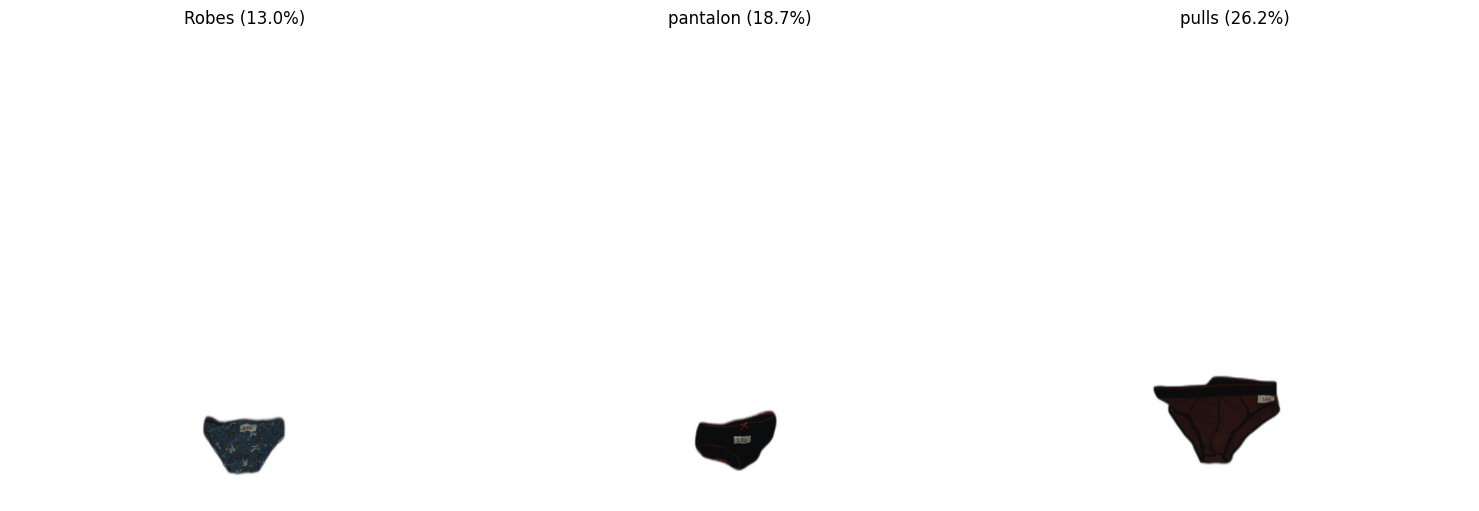

In [64]:
from ultralytics import YOLO
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt

# Charger le modèle
model = YOLO("runs/classify/train2/weights/best.pt")  # ← adapte le chemin

# Dossier contenant les images
custom_test_dir = Path("image_test\Culottes, slip")  # ← adapte le dossier

# Récupérer les images .png
image_paths = list(custom_test_dir.glob("*.png"))

# Sélectionner jusqu'à 3 images aléatoires

selected_images = random.sample(image_paths, min(3, len(image_paths)))

# Préparer les figures
plt.figure(figsize=(15, 5))  # Taille horizontale

for i, img_path in enumerate(selected_images):
    # Prédiction
    result = model(img_path)
    probs = result[0].probs
    pred_class = probs.top1
    conf = probs.top1conf.item()
    class_name = model.names[pred_class]
    
    # Lecture de l'image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Affichage
    plt.subplot(1, 3, i+1)  # 1 ligne, 3 colonnes
    plt.imshow(img_rgb)
    plt.title(f"{class_name} ({conf:.1%})")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Resnet50

In [13]:
import torch
print(torch.cuda.is_available())  # True si CUDA dispo
print(torch.cuda.device_count())  # Nombre de GPUs détectés


True
1


In [14]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


2.5.1+cu121
12.1
True
1
NVIDIA RTX A5000


In [34]:
#! pip uninstall numpy
#! pip install numpy


In [35]:
import numpy
import torch
from PIL import Image
import numpy as np

# création d'une image PIL
img = Image.new('RGB', (10, 10))

# conversion en numpy array puis tensor torch
arr = np.array(img)
tensor = torch.from_numpy(arr)

print(tensor.shape)


torch.Size([10, 10, 3])


In [36]:
import numpy
print(numpy.__version__)


2.1.3


c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BureauCETIA\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


📟 Using device: cuda
Epoch 1/10 - Train Loss: 2.2008, Val Loss: 2.0194, Train Acc: 50.32%, Val Acc: 47.74%, AUC: 0.6111
📦 Best model saved.
Epoch 2/10 - Train Loss: 1.6634, Val Loss: 1.4459, Train Acc: 53.82%, Val Acc: 54.19%, AUC: 0.6798
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.2985, Val Loss: 1.2461, Train Acc: 59.35%, Val Acc: 60.65%, AUC: 0.7190
📦 Best model saved.
Epoch 4/10 - Train Loss: 1.1177, Val Loss: 1.1055, Train Acc: 61.75%, Val Acc: 61.29%, AUC: 0.7419
📦 Best model saved.
Epoch 5/10 - Train Loss: 0.9838, Val Loss: 1.0494, Train Acc: 67.10%, Val Acc: 67.10%, AUC: 0.7987
📦 Best model saved.
Epoch 6/10 - Train Loss: 0.8504, Val Loss: 0.8723, Train Acc: 73.82%, Val Acc: 74.84%, AUC: 0.7866
📦 Best model saved.
Epoch 7/10 - Train Loss: 0.7231, Val Loss: 0.7430, Train Acc: 79.17%, Val Acc: 77.42%, AUC: 0.8115
📦 Best model saved.
Epoch 8/10 - Train Loss: 0.6171, Val Loss: 0.6948, Train Acc: 80.37%, Val Acc: 78.71%, AUC: 0.8342
📦 Best model saved.
Epoch 9/10 - Train Loss: 0.

2025/07/16 14:42:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 10/10 - Train Loss: 0.4823, Val Loss: 0.6552, Train Acc: 82.67%, Val Acc: 80.00%, AUC: 0.8550


2025/07/16 14:42:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/07/16 14:42:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🏁 Best Validation Accuracy: 79.35%


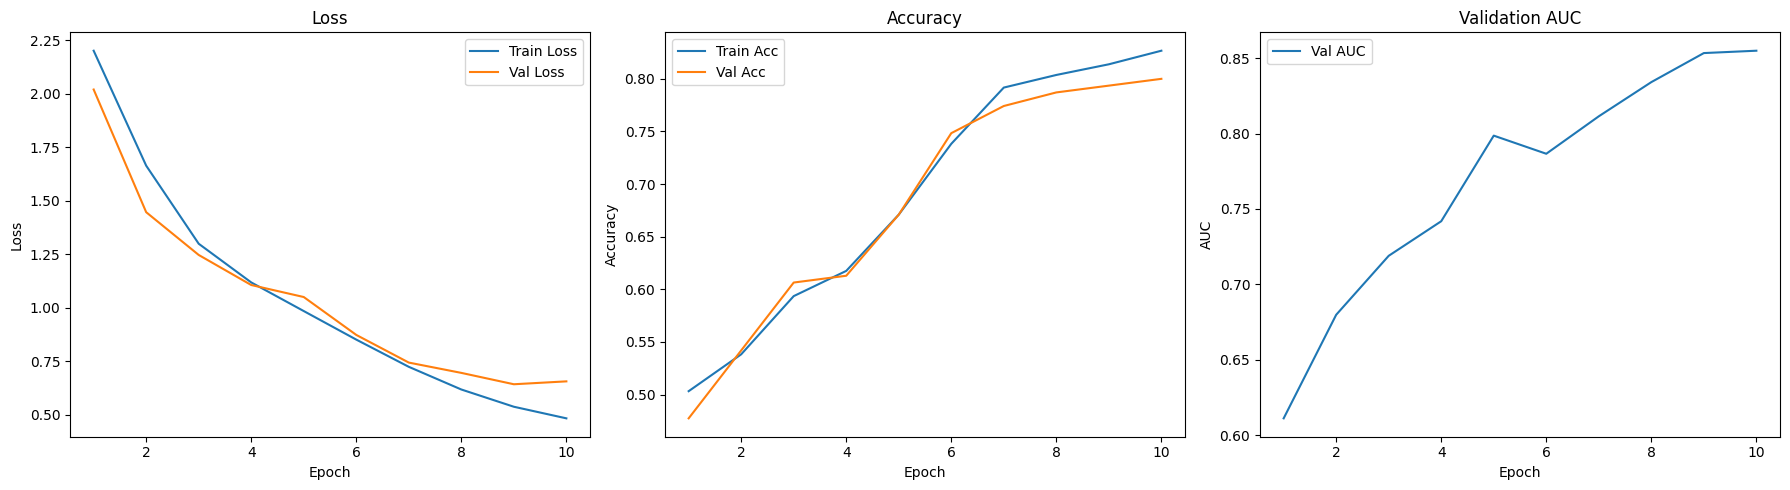

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\731618249.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [15]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)



model_resnet, history_resnet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(label_encoder.classes_),
    model_name="resnet50",
    lr=1e-4,
    early_stopping_patience=3,
    best_model_path= "./model/best_model_resnet.pth"
)



In [16]:
class_names = label_encoder.classes_
class_names

array(['Bas Court', 'Bas Long', 'Bas court', 'Haut', 'Haut MC', 'Haut ML',
       'Jupes', 'Robes', 'Soutien_gorge/brassiere/Haut_maillot',
       'combinaison/body', 'manteau', 'peignoir'], dtype=object)

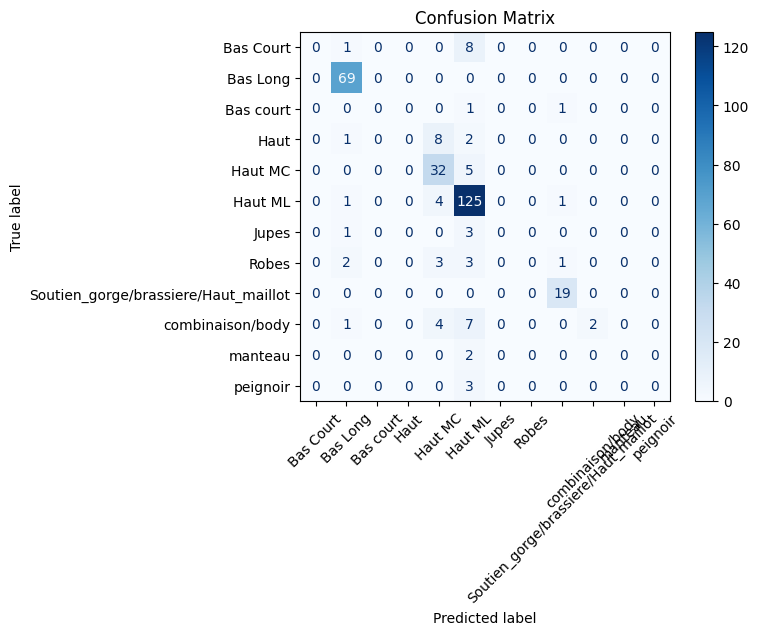

In [17]:
# Crée tes DataLoaders
_, val_loader, _ = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)
_, _, test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)


# Utilise la liste des classes dans l'ordre du LabelEncoder
class_names = label_encoder.classes_
# Passe cette liste à ta fonction de plot
plot_confusion_matrix(model_resnet, test_loader, class_names=class_names)


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)

evaluate_on_test(model_resnet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.91      1.00      0.95        69
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00        11
           4       0.63      0.86      0.73        37
           5       0.79      0.95      0.86       131
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         9
           8       0.86      1.00      0.93        19
           9       1.00      0.14      0.25        14
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         3

    accuracy                           0.80       310
   macro avg       0.35      0.33      0.31       310
weighted avg       0.71      0.80      0.73       310



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

# Vgg16

📟 Using device: cuda
Epoch 1/10 - Train Loss: 0.7479, Val Loss: 0.7333, Train Acc: 79.45%, Val Acc: 82.58%, AUC: 0.9415
📦 Best model saved.
Epoch 2/10 - Train Loss: 0.1943, Val Loss: 0.3670, Train Acc: 93.55%, Val Acc: 92.90%, AUC: 0.9708
📦 Best model saved.
Epoch 3/10 - Train Loss: 0.1043, Val Loss: 0.5457, Train Acc: 97.14%, Val Acc: 88.39%, AUC: 0.9798
Epoch 4/10 - Train Loss: 0.0577, Val Loss: 0.5576, Train Acc: 97.97%, Val Acc: 89.68%, AUC: 0.9800


2025/07/16 14:45:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 5/10 - Train Loss: 0.0350, Val Loss: 0.4799, Train Acc: 98.89%, Val Acc: 90.32%, AUC: 0.9790
⏹️ Early stopping triggered.


2025/07/16 14:45:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/07/16 14:45:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🏁 Best Validation Accuracy: 92.90%


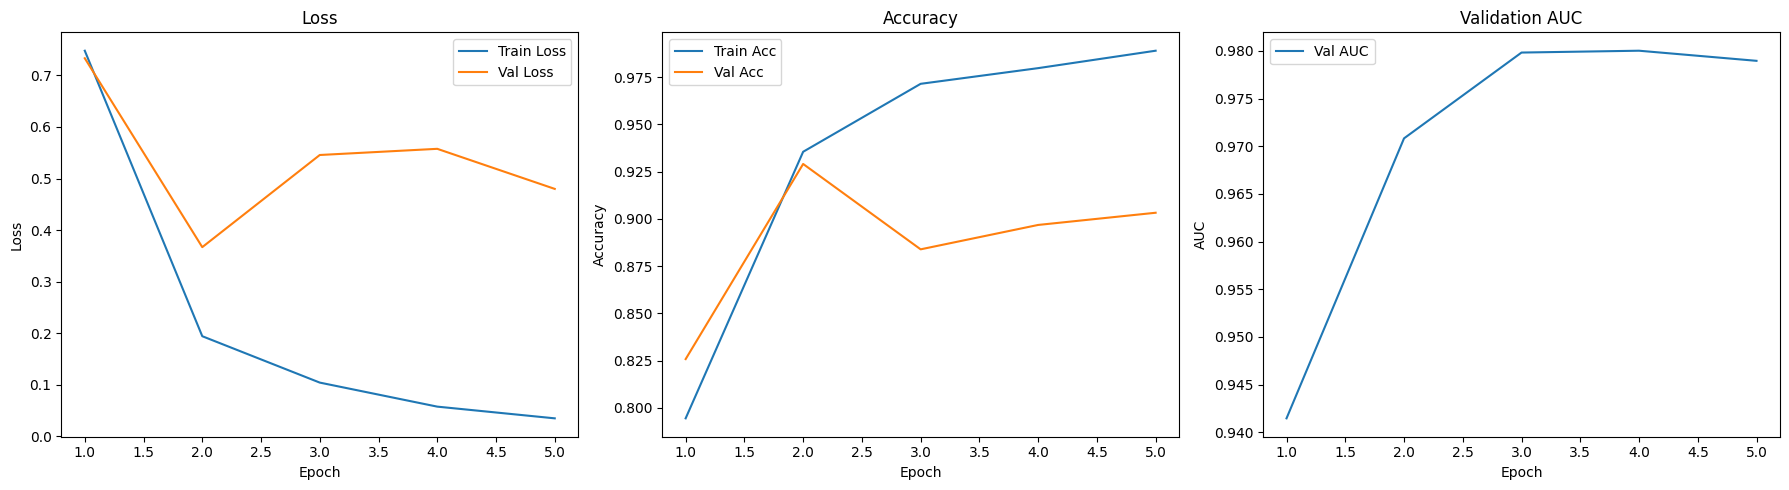

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\731618249.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [19]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)



model_vgg16, history_vgg16 = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(label_encoder.classes_),
    model_name="vgg16",
    lr=1e-4,
    early_stopping_patience=3,
    best_model_path= "./model/best_model_vgg16.pth"
)


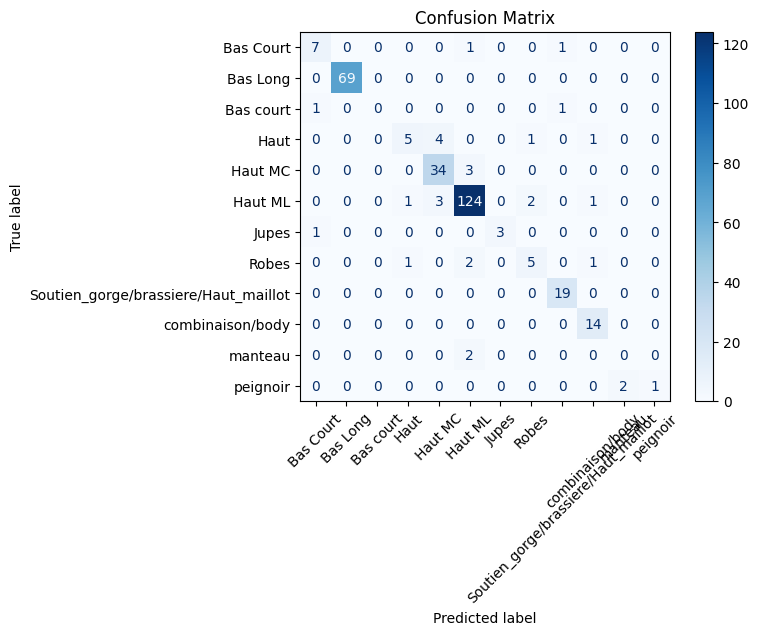

In [20]:
_, val_loader, _ = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)

_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)

# Utilise la liste des classes dans l'ordre du LabelEncoder
class_names = label_encoder.classes_

# Passe cette liste à ta fonction de plot
plot_confusion_matrix(model_vgg16, test_loader, class_names=class_names)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)

evaluate_on_test(model_vgg16, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       1.00      1.00      1.00        69
           2       0.00      0.00      0.00         2
           3       0.71      0.45      0.56        11
           4       0.83      0.92      0.87        37
           5       0.94      0.95      0.94       131
           6       1.00      0.75      0.86         4
           7       0.62      0.56      0.59         9
           8       0.90      1.00      0.95        19
           9       0.82      1.00      0.90        14
          10       0.00      0.00      0.00         2
          11       1.00      0.33      0.50         3

    accuracy                           0.91       310
   macro avg       0.72      0.64      0.66       310
weighted avg       0.90      0.91      0.90       310



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

# GoogleNet

📟 Using device: cuda
Epoch 1/10 - Train Loss: 0.9933, Val Loss: 0.5269, Train Acc: 72.53%, Val Acc: 84.52%, AUC: 0.9570
📦 Best model saved.
Epoch 2/10 - Train Loss: 0.1164, Val Loss: 0.4614, Train Acc: 96.68%, Val Acc: 87.10%, AUC: 0.9746
📦 Best model saved.
Epoch 3/10 - Train Loss: 0.0229, Val Loss: 0.4288, Train Acc: 99.72%, Val Acc: 90.97%, AUC: 0.9803
📦 Best model saved.
Epoch 4/10 - Train Loss: 0.0131, Val Loss: 0.4619, Train Acc: 99.72%, Val Acc: 92.26%, AUC: 0.9760
Epoch 5/10 - Train Loss: 0.0064, Val Loss: 0.4311, Train Acc: 100.00%, Val Acc: 89.68%, AUC: 0.9825


2025/07/16 14:48:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/16 14:48:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 6/10 - Train Loss: 0.0024, Val Loss: 0.4328, Train Acc: 100.00%, Val Acc: 91.61%, AUC: 0.9838
⏹️ Early stopping triggered.


2025/07/16 14:48:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🏁 Best Validation Accuracy: 90.97%


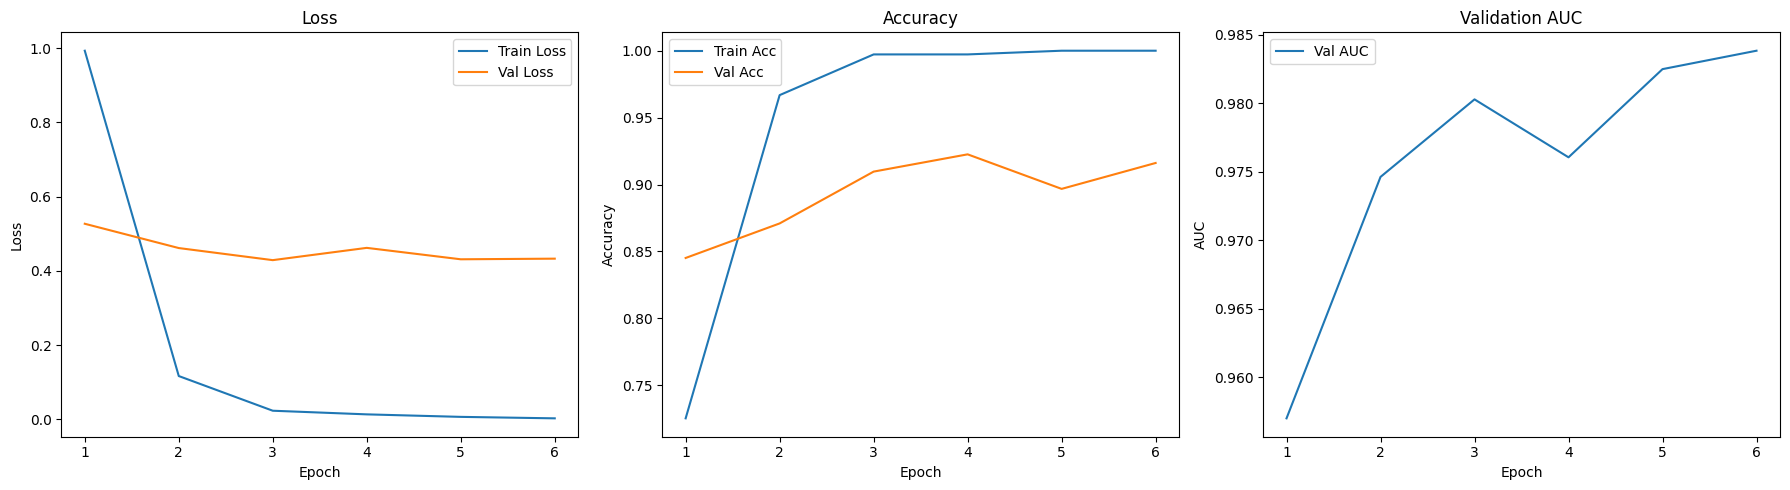

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\731618249.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [22]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)



model_googlenet, history_googlenet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(label_encoder.classes_),
    model_name="inception_v3",
    lr=1e-4,
    early_stopping_patience=3,
    best_model_path= "./model/best_model_googlenet.pth"

)


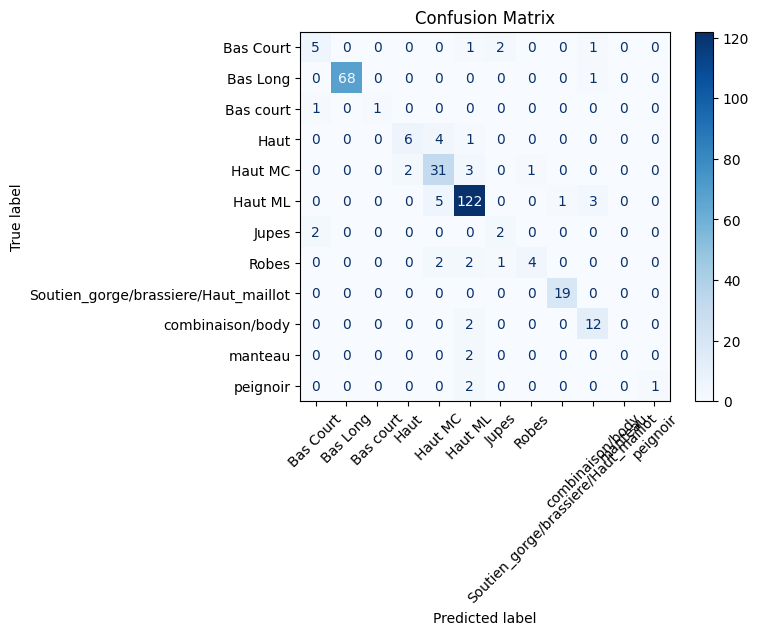

In [23]:
_, val_loader, _ = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)

_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)

# Utilise la liste des classes dans l'ordre du LabelEncoder
class_names = label_encoder.classes_

# Passe cette liste à ta fonction de plot
plot_confusion_matrix(model_googlenet, test_loader, class_names=class_names)

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)

evaluate_on_test(model_googlenet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.62      0.56      0.59         9
           1       1.00      0.99      0.99        69
           2       1.00      0.50      0.67         2
           3       0.75      0.55      0.63        11
           4       0.74      0.84      0.78        37
           5       0.90      0.93      0.92       131
           6       0.40      0.50      0.44         4
           7       0.80      0.44      0.57         9
           8       0.95      1.00      0.97        19
           9       0.71      0.86      0.77        14
          10       0.00      0.00      0.00         2
          11       1.00      0.33      0.50         3

    accuracy                           0.87       310
   macro avg       0.74      0.62      0.65       310
weighted avg       0.87      0.87      0.87       310



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

In [27]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

def test_random_images_by_category_from_loader(model, test_loader, label_encoder, device, target_label, num_images=6):
    """
    Affiche des images aléatoires d'une catégorie spécifique provenant du test_loader avec prédictions.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
        target_label: nom de la catégorie ciblée (ex: 'blousechemise').
        num_images: nombre d'images à afficher.
    """
    model.eval()
    model.to(device)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    target_idx = label_encoder.transform([target_label])[0]

    filtered_images = []
    filtered_labels = []

    # Parcours du loader pour collecter les images correspondant à la catégorie
    for images, labels in test_loader:
        for img, label in zip(images, labels):
            if label.item() == target_idx:
                filtered_images.append(img)
                filtered_labels.append(label)

    if len(filtered_images) == 0:
        print(f"Aucune image trouvée pour la catégorie '{target_label}'.")
        return

    num_images = min(num_images, len(filtered_images))
    selected_indices = random.sample(range(len(filtered_images)), num_images)

    selected_images = torch.stack([filtered_images[i] for i in selected_indices]).to(device)

    with torch.no_grad():
        outputs = model(selected_images)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

    selected_images = selected_images.cpu()
    preds = preds.cpu()
    confidences = confidences.cpu()

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        img = selected_images[i].permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        img_resized = cv2.resize(img, (512, 512))
        img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img_resized)
        plt.axis('off')

        pred_class = label_encoder.inverse_transform([preds[i].item()])[0]
        conf = confidences[i].item()
        plt.title(f"Prédit : {pred_class}\nConf : {conf:.2f}")

    plt.tight_layout()
    plt.show()


# Test modeles

In [ ]:
'''import os

def get_image_paths(folder_path):
    image_extensions = ('.jpg', '.jpeg', '.png')

    image_paths = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(image_extensions)
    ]
    
    return image_paths'''


"import os\n\ndef get_image_paths(folder_path):\n    image_extensions = ('.jpg', '.jpeg', '.png')\n\n    image_paths = [\n        os.path.join(folder_path, f)\n        for f in os.listdir(folder_path)\n        if f.lower().endswith(image_extensions)\n    ]\n\n    return image_paths"

In [25]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_resnet = timm.create_model("resnet50", pretrained=False, num_classes=len(label_encoder.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_resnet.pth", map_location=torch.device('cpu'))
model_resnet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_resnet.eval()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\4137673432.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_resnet.pth", 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

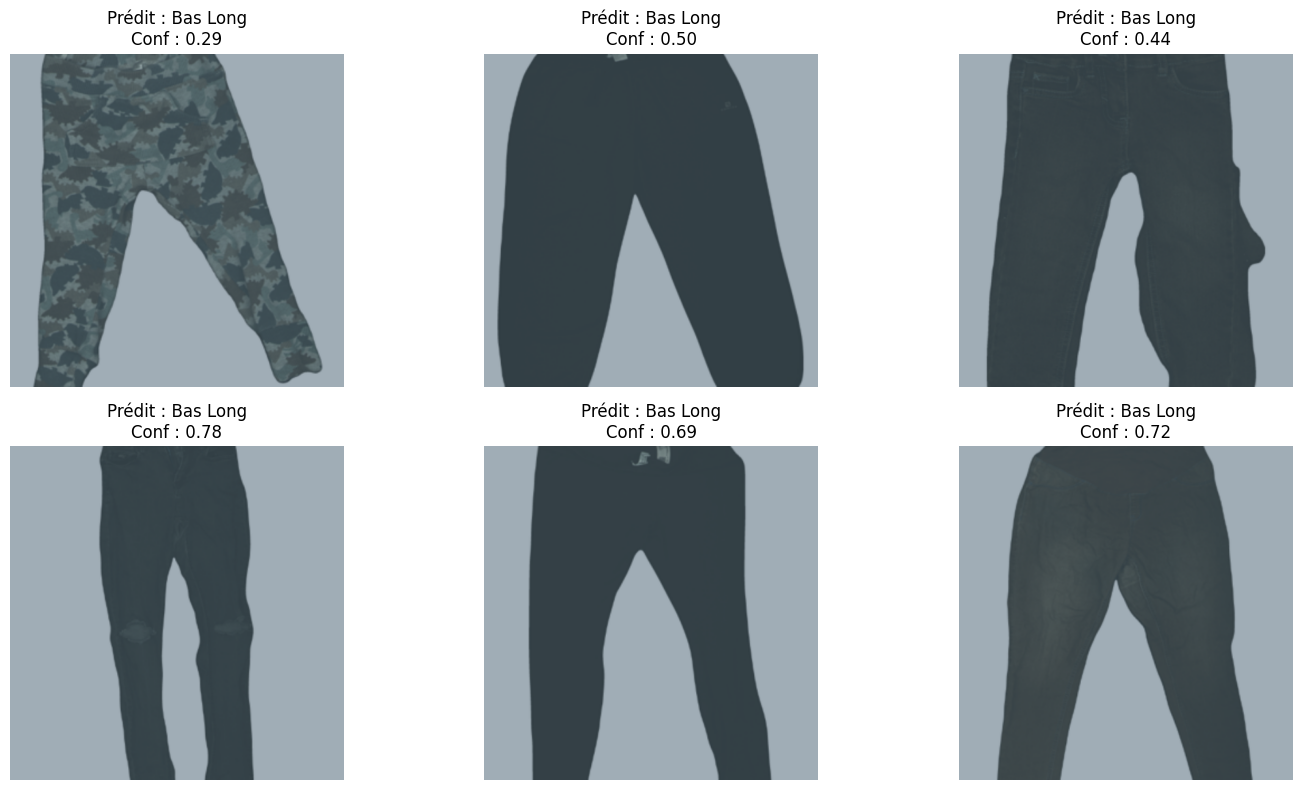

In [32]:
test_random_images_by_category_from_loader(
    model=model_resnet,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device,
    target_label="Bas Long",
    num_images=6
)


In [33]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_vgg16 = timm.create_model("vgg16", pretrained=False, num_classes=len(label_encoder.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_vgg16.pth", map_location=torch.device('cpu'))
model_vgg16.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_vgg16.eval()

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\1836813471.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_vgg16.pth", m

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

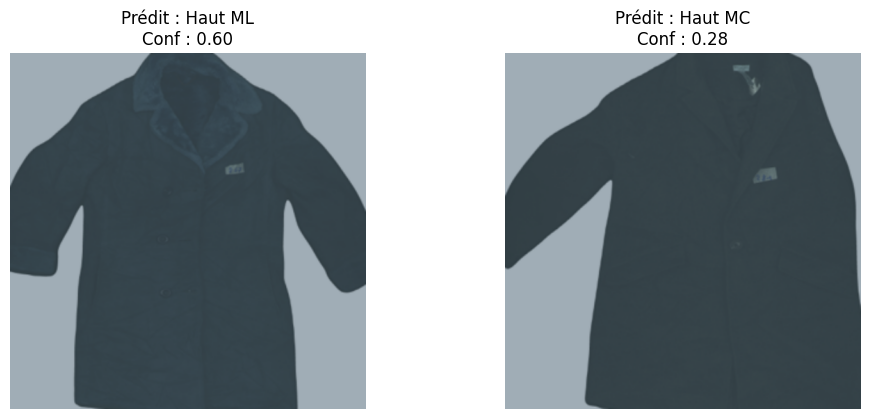

In [35]:
test_random_images_by_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device,
    target_label="manteau",
    num_images=6
)


In [36]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_googlenet = timm.create_model("inception_v3", pretrained=False, num_classes=len(label_encoder.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_googlenet.pth", map_location=torch.device('cpu'))
model_googlenet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_googlenet.eval()

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_6964\4229598238.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_googlenet.pth

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

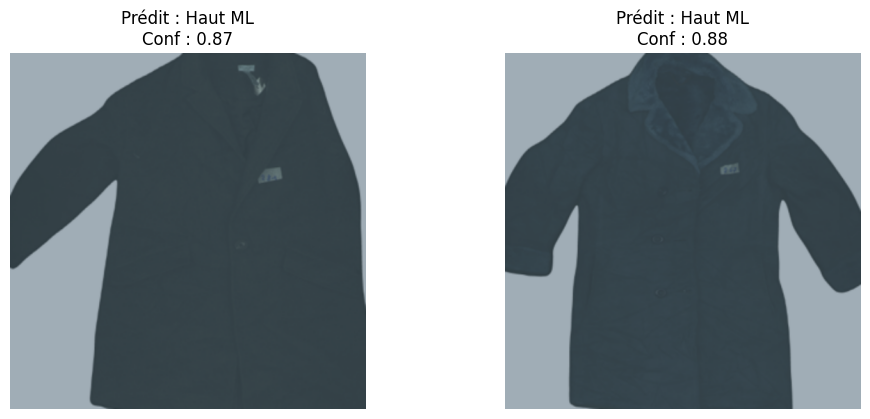

In [37]:
test_random_images_by_category_from_loader(
    model=model_googlenet,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device,
    target_label="manteau",
    num_images=6
)


In [38]:
import torch
import torch.nn.functional as F

def evaluate_model_per_category_from_loader(model, test_loader, label_encoder, device):
    """
    Évalue le modèle sur chaque catégorie présente dans le test_loader,
    affiche la précision par catégorie.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
    """
    model.eval()
    model.to(device)

    num_classes = len(label_encoder.classes_)
    correct_per_class = [0] * num_classes
    total_per_class = [0] * num_classes

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for true_label, pred_label in zip(labels, preds):
                total_per_class[true_label.item()] += 1
                if true_label.item() == pred_label.item():
                    correct_per_class[true_label.item()] += 1

    print("\n📊 Résultats par catégorie :\n")
    for idx, class_name in enumerate(label_encoder.classes_):
        total = total_per_class[idx]
        correct = correct_per_class[idx]
        accuracy = (correct / total * 100) if total > 0 else 0
        print(f"✅ Classe '{class_name}': {correct}/{total} images correctement classées ({accuracy:.2f}%)")


In [39]:
evaluate_model_per_category_from_loader(
    model=model_googlenet,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device
)



📊 Résultats par catégorie :

✅ Classe 'Bas Court': 5/9 images correctement classées (55.56%)
✅ Classe 'Bas Long': 68/69 images correctement classées (98.55%)
✅ Classe 'Bas court': 1/2 images correctement classées (50.00%)
✅ Classe 'Haut': 6/11 images correctement classées (54.55%)
✅ Classe 'Haut MC': 31/37 images correctement classées (83.78%)
✅ Classe 'Haut ML': 122/131 images correctement classées (93.13%)
✅ Classe 'Jupes': 2/4 images correctement classées (50.00%)
✅ Classe 'Robes': 4/9 images correctement classées (44.44%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 19/19 images correctement classées (100.00%)
✅ Classe 'combinaison/body': 12/14 images correctement classées (85.71%)
✅ Classe 'manteau': 0/2 images correctement classées (0.00%)
✅ Classe 'peignoir': 1/3 images correctement classées (33.33%)


In [40]:
evaluate_model_per_category_from_loader(
    model=model_resnet,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device
)



📊 Résultats par catégorie :

✅ Classe 'Bas Court': 0/9 images correctement classées (0.00%)
✅ Classe 'Bas Long': 69/69 images correctement classées (100.00%)
✅ Classe 'Bas court': 0/2 images correctement classées (0.00%)
✅ Classe 'Haut': 0/11 images correctement classées (0.00%)
✅ Classe 'Haut MC': 30/37 images correctement classées (81.08%)
✅ Classe 'Haut ML': 77/131 images correctement classées (58.78%)
✅ Classe 'Jupes': 0/4 images correctement classées (0.00%)
✅ Classe 'Robes': 0/9 images correctement classées (0.00%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 15/19 images correctement classées (78.95%)
✅ Classe 'combinaison/body': 5/14 images correctement classées (35.71%)
✅ Classe 'manteau': 0/2 images correctement classées (0.00%)
✅ Classe 'peignoir': 0/3 images correctement classées (0.00%)


In [41]:
evaluate_model_per_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=label_encoder,
    device=device
)


📊 Résultats par catégorie :

✅ Classe 'Bas Court': 3/9 images correctement classées (33.33%)
✅ Classe 'Bas Long': 68/69 images correctement classées (98.55%)
✅ Classe 'Bas court': 0/2 images correctement classées (0.00%)
✅ Classe 'Haut': 5/11 images correctement classées (45.45%)
✅ Classe 'Haut MC': 36/37 images correctement classées (97.30%)
✅ Classe 'Haut ML': 112/131 images correctement classées (85.50%)
✅ Classe 'Jupes': 1/4 images correctement classées (25.00%)
✅ Classe 'Robes': 2/9 images correctement classées (22.22%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 17/19 images correctement classées (89.47%)
✅ Classe 'combinaison/body': 13/14 images correctement classées (92.86%)
✅ Classe 'manteau': 0/2 images correctement classées (0.00%)
✅ Classe 'peignoir': 0/3 images correctement classées (0.00%)
